# Method 2: J2 Involution / T_256 Eigenspectrum

**Ainulindale Engine** — Tier udeo_crypto

Cody's method 2 — H_hat_RB vs H_hat_BR as L-R in T_256. At chance. wiki/53 checklist unchecked.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import importlib.util, math, cmath, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

def load_maths(tier):
    paths = {7: '../../modules/tier7_cosmos/maths.py',
             8: '../../modules/tier8_sedenion/maths.py',
             9: '../../modules/tier9_chem/maths.py',
             'udeo_crypto': '../../modules/udeo_crypto/UDEO_RSA_DEMO.py'}
    spec = importlib.util.spec_from_file_location(f't{tier}', paths[tier])
    m = importlib.util.module_from_spec(spec); spec.loader.exec_module(m)
    return m

OMEGA_ZS = 0.5671432904097838
D_STAR   = 0.24600
GAP      = OMEGA_ZS - D_STAR * math.log(10)
R_H      = 1.0 / math.sqrt(2.0)
RIEMANN_ZEROS = [14.134725, 21.022040, 25.010858, 30.424876, 32.935062,
                 37.586178, 40.918719, 43.327073, 48.005151, 49.773832]
print("Ainulindale notebook ready.")


Ainulindale notebook ready.


In [2]:
m = load_maths('udeo_crypto')
result = m.method2_j2_involution_t256()
print("Claim:", result['claim'])
print("Confidence:", result['confidence'])


Claim: Method 2 (J2 involution / T_256): does d_s align with a dominant eigenvector of L_{e_s} - R_{e_s}?
Confidence: OPEN


## Engine Output

In [3]:
import pprint
pprint.pprint({k: v for k, v in result.items()
               if k not in ('claim', 'confidence', 'latex')}, width=100, depth=3)


{'chance_baseline': 50.0,
 'interpretation_caveat': "wiki/53's formal-target checklist (its own closing section) explicitly "
                          "leaves 'state the complexity result' and 'prove or bound this claim' as "
                          'open, unchecked items. The H_hat_RB <-> H_hat_BR / J2 / T_256 machinery '
                          'has no prior code implementation anywhere in the repo — this is a '
                          'first, literal, and necessarily provisional reading of an '
                          'underspecified theoretical note, not a validated mechanism.',
 'mean_percentile_rank': 56.77,
 'per_key': [{'asymmetry_operator_norm': 31.874755,
              'control_mean_alignment': 0.01128,
              'd': 103,
              'e': 7,
              'n': 143,
              'true_d_alignment': 0.0,
              'true_d_percentile_vs_controls': 51.72},
             {'asymmetry_operator_norm': 31.874755,
              'control_mean_alignment': 0.029848,
  

## Mathematical Foundation

$$\text{LaTeX: }\quad \Delta=L_{e_s}-R_{e_s}\ \text{in}\ T_{256}$$

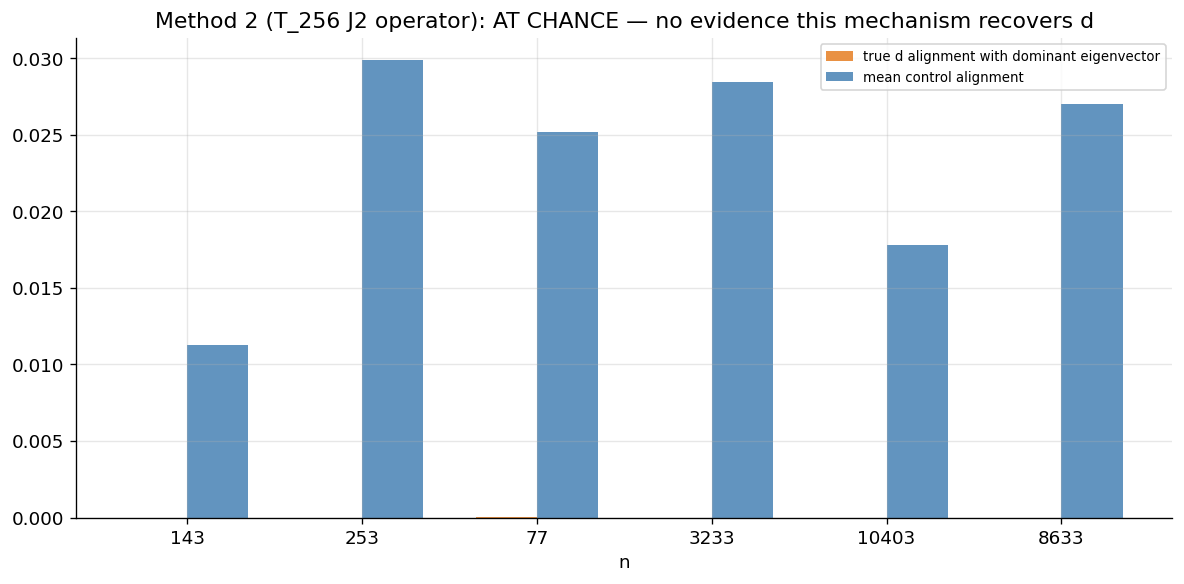

Mean percentile rank vs chance(50): 56.77
wiki/53's formal-target checklist (its own closing section) explicitly leaves 'state the complexity result' and 'prove or bound this claim' as open, unchecked items. The H_hat_RB <-> H_hat_BR / J2 / T_256 machinery has no prior code implementation anywhere in the repo — this is a first, literal, and necessarily provisional reading of an underspecified theoretical note, not a validated mechanism.


In [4]:

fig, ax = plt.subplots(figsize=(10, 5))
rows = result['per_key']
ns = [str(row['n']) for row in rows]
true_a = [row['true_d_alignment'] for row in rows]
ctrl_a = [row['control_mean_alignment'] for row in rows]
x = np.arange(len(ns)); w = 0.35
ax.bar(x - w/2, true_a, w, label='true d alignment with dominant eigenvector', color='#E67E22', alpha=0.85)
ax.bar(x + w/2, ctrl_a, w, label='mean control alignment', color='steelblue', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ns); ax.set_xlabel('n')
ax.set_title(f"Method 2 (T_256 J2 operator): {result['verdict']}")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Mean percentile rank vs chance(50):', result['mean_percentile_rank'])
print(result['interpretation_caveat'])


## Ainulindale Reading

**Confidence:** `{}'.format(result.get('confidence',''))`

Run `result.keys()` to explore the full engine output.

In [5]:
print('Engine keys:', list(result.keys()))

Engine keys: ['claim', 'per_key', 'mean_percentile_rank', 'chance_baseline', 'verdict', 'confidence', 'interpretation_caveat']
